In [2]:
# Packages for data analysis
import os
import numpy as np
import pandas as pd

from sklearn import svm

# Visual your data
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(font_scale=1.2)

%matplotlib inline


In [3]:
file_path = os.path.join('data', 'cupcakes_vs_muffins_recipes.csv')
recipes = pd.read_csv(file_path)
print(recipes.head())


   Flour  Sugar  Butter  Egg  Milk  Baking_Powder  Vanilla     Type
0    267    100      76    1   206            3.9      0.3   muffin
1    127    121      99    2    54            2.4      2.1  cupcake
2    155    137     130    1   100            2.5      3.2  cupcake
3    278     59      89    1   236            5.5      2.0   muffin
4    260     40      45    2   211            3.3      1.7   muffin


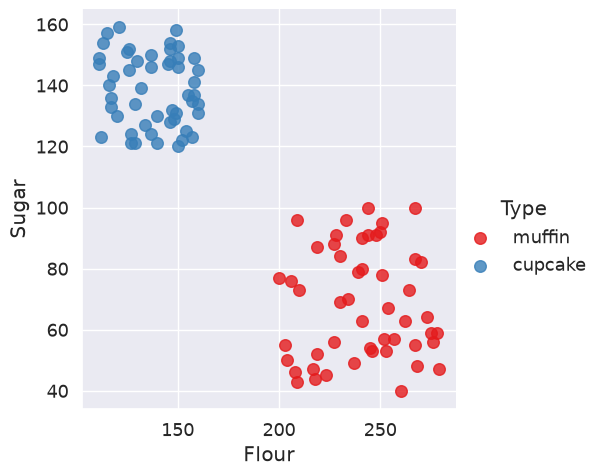

In [4]:
# Plot our data
sns.lmplot(x='Flour', y='Sugar', data=recipes, hue='Type',
           palette='Set1', fit_reg=False, scatter_kws={"s": 70})


In [9]:
# Format or pre-process our data
type_label = np.where(recipes['Type'] == 'muffin', 0 , 1)
recipes_features = recipes.columns.values[1:].tolist() # ['Flour', 'Sugar', 'Butter', 'Eggs', 'Milk']
ingredients = recipes[["Flour","Sugar"]].values
print(ingredients)

[[267 100]
 [127 121]
 [155 137]
 [278  59]
 [260  40]
 [150 146]
 [137 124]
 [241  90]
 [248  91]
 [206  76]
 [217  47]
 [126 145]
 [252  57]
 [149 158]
 [251  78]
 [127 124]
 [244 100]
 [234  70]
 [113 154]
 [279  47]
 [158 141]
 [117 136]
 [219  87]
 [241  63]
 [149 131]
 [241  80]
 [209  43]
 [210  73]
 [230  84]
 [120 130]
 [146 152]
 [115 157]
 [160 145]
 [157 135]
 [140 130]
 [111 147]
 [200  77]
 [219  52]
 [158 137]
 [250  92]
 [116 140]
 [233  96]
 [203  55]
 [118 143]
 [129 121]
 [146 148]
 [208  46]
 [267  55]
 [228  91]
 [239  79]
 [275  59]
 [112 123]
 [227  88]
 [132 139]
 [130 148]
 [150 120]
 [218  44]
 [111 149]
 [140 121]
 [244  91]
 [125 151]
 [257  57]
 [254  67]
 [276  56]
 [264  73]
 [246  53]
 [268  48]
 [126 152]
 [160 131]
 [147 132]
 [230  69]
 [270  82]
 [152 122]
 [129 134]
 [273  64]
 [251  95]
 [245  54]
 [134 127]
 [117 133]
 [145 147]
 [267  83]
 [148 129]
 [146 128]
 [262  63]
 [121 159]
 [237  49]
 [146 154]
 [253  53]
 [150 153]
 [137 150]
 [157 123]

In [ ]:
# Fit the SVM (Support Vector Machine) model
model = svm.SVC(kernel = 'linear') # Create an SVM model with a linear kernel
model.fit(ingredients, type_label)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [15]:
# Get the separating hyperplane
w = model.coef_[0] # weights
a = -w[0] / w[1] # slope
xx = np.linspace(100, 300) # x values
yy = a * xx - (model.intercept_[0]) / w[1] # y = mx + b
print(yy)

# Plot the parallel lines that pass through the support vectors
b = model.support_vectors_[0] # first support vector
yy_down = a * xx + (b[1] - a * b[0]) # line below the hyperplane
b = model.support_vectors_[-1] # last support vector
yy_up = a * xx + (b[1] - a*b[0]) # line above the hyperplane

[-50.35185185 -42.49092971 -34.63000756 -26.76908541 -18.90816327
 -11.04724112  -3.18631897   4.67460317  12.53552532  20.39644747
  28.25736961  36.11829176  43.97921391  51.84013605  59.7010582
  67.56198035  75.42290249  83.28382464  91.14474679  99.00566893
 106.86659108 114.72751323 122.58843537 130.44935752 138.31027967
 146.17120181 154.03212396 161.89304611 169.75396825 177.6148904
 185.47581255 193.33673469 201.19765684 209.05857899 216.91950113
 224.78042328 232.64134543 240.50226757 248.36318972 256.22411187
 264.08503401 271.94595616 279.80687831 287.66780045 295.5287226
 303.38964475 311.25056689 319.11148904 326.97241119 334.83333333]


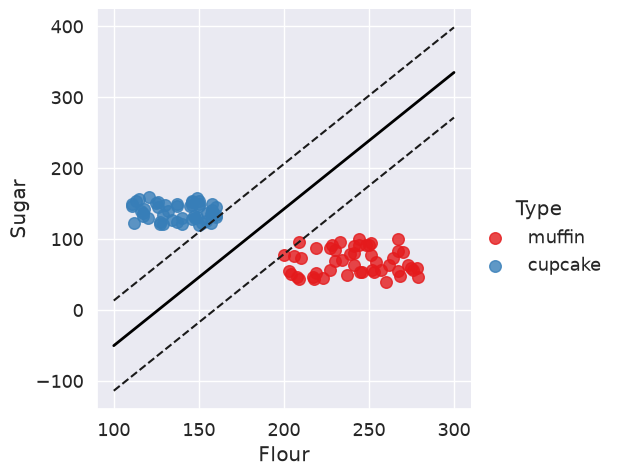

In [16]:
sns.lmplot(x='Flour', y='Sugar', data=recipes, hue='Type', 
           palette='Set1', fit_reg=False, scatter_kws={"s": 70})
plt.plot(xx, yy, linewidth=2, color='black') # hyperplane
plt.plot(xx, yy_down, 'k--') # dashed line below hyperplane
plt.plot(xx, yy_up, 'k--') # dashed line above hyperplane   

In [ ]:
# Create a function to predict the type of recipe is muffin or cupcake based on the amount of flour and sugar
def predict_recipe_type(flour, sugar):
    prediction = model.predict([[flour, sugar]]) # predict the type of recipe based on the amount of flour and sugar
    if prediction == 0:
        print("The recipe is a muffin.")
        return "muffin"
        
    else:
        print("The recipe is a cupcake.")
        return "cupcake"

predict_recipe_type(200, 150) # Test the function with 200g of flour and 150g of sugar


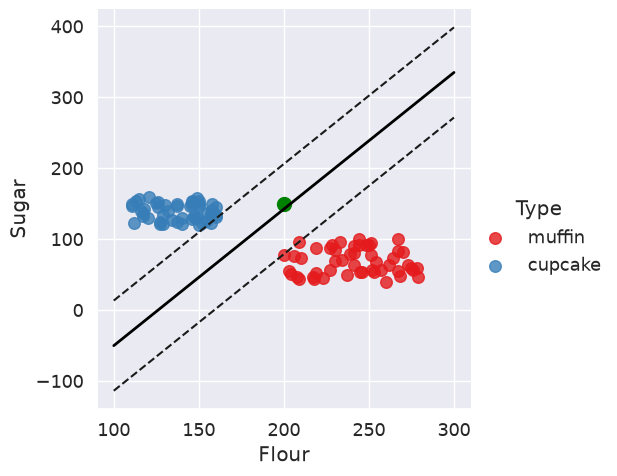

In [18]:
# Let plot this prediction on the graph
sns.lmplot(x='Flour', y='Sugar', data=recipes, hue='Type', 
           palette='Set1', fit_reg=False, scatter_kws={"s": 70})
plt.plot(xx, yy, linewidth=2, color='black') # hyperplane
plt.plot(xx, yy_down, 'k--') # dashed line below hyperplane
plt.plot(xx, yy_up, 'k--') # dashed line above hyperplane
plt.scatter(200, 150, color='green', s=100) # plot the
    